In [1]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/sdtools"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


# SOLPS I/O

In [2]:
case = SOLPScase('/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-10_SOLPS_analysis/puff=13.0e21_pump=0.001_divchiconstfix_bcmom2_visper1_rxf0p1_parmvsa2_redoutpfrtrans_pufflfs_pin1.0/')


In [3]:
raw_balance = nc.Dataset(os.path.join('/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-10_SOLPS_analysis/puff=13.0e21_pump=0.001_divchiconstfix_bcmom2_visper1_rxf0p1_parmvsa2_redoutpfrtrans_pufflfs_pin1.0/', "balance.nc"))


# Create a dictionary with all variables (no 'self' needed)
bal = {}
for key in raw_balance.variables:
    bal[key] = raw_balance[key][:].transpose()

# Now you can access anything
print(bal["te"])  # Charge exchange rates

raw_balance.close()

[[1.89581983e-19 2.01029934e-19 2.16501272e-19 ... 9.64855085e-19
  9.33739921e-19 8.71980367e-19]
 [1.89962569e-19 2.01429564e-19 2.17223254e-19 ... 9.66036906e-19
  9.34563877e-19 8.72678390e-19]
 [1.91452758e-19 2.03067155e-19 2.20130834e-19 ... 9.71188141e-19
  9.38093795e-19 8.75419913e-19]
 ...
 [3.18119910e-20 5.29965999e-20 4.98184497e-20 ... 2.60359665e-20
  2.32210608e-20 2.27703880e-20]
 [2.52547493e-20 4.10883419e-20 3.99649549e-20 ... 2.14405330e-20
  1.91652108e-20 1.88327348e-20]
 [1.72131538e-20 2.61076480e-20 2.27754665e-20 ... 1.78881365e-20
  1.60645331e-20 1.58094116e-20]]


In [ ]:

params_sorted = sorted(case.params)
n_cols = 4
params_array = np.array_split(params_sorted, n_cols)

for row in zip(*params_array):
    print(f"{row[0]:<30} {row[1]:<30} {row[2] if len(row) > 2 else '':<30}")

Bpol                           eirene_mc_piat_sna_bal         fmoy_C+1_tot                  
Btor                           eirene_mc_piio_sna_bal         fmoy_C+2_cvsa                 
Btot                           eirene_mc_piml_sna_bal         fmoy_C+2_flua                 
M                              eirene_mc_pipl_sna_bal         fmoy_C+2_tot                  
NVd+                           eirene_mc_pmat_sna_bal         fmoy_C+3_cvsa                 
Na                             eirene_mc_pmel_sne_bal         fmoy_C+3_flua                 
Ne                             eirene_mc_pmio_sna_bal         fmoy_C+3_tot                  
Nm                             eirene_mc_pmml_sna_bal         fmoy_C+4_cvsa                 
Nn                             eirene_mc_pmpl_sna_bal         fmoy_C+4_flua                 
Pa                             eirene_mc_pppl_sna_bal         fmoy_C+4_tot                  
Pd+                            ev                             fmoy_C+5

In [16]:
print(case.params)

['crx', 'cry', 'bb', 'hx', 'hy', 'hz', 'vol', 'gs', 'qz', 'am', 'mp', 'ev', 'leftix', 'leftiy', 'rightix', 'rightiy', 'topix', 'topiy', 'bottomix', 'bottomiy', 'jxi', 'jxa', 'jsep', 'species', 'b2mndr_eirene', 'b2mndr_hz', 'za', 'fna_pinch', 'fna_pll', 'fna_drift', 'fna_drift_50', 'fna_ch', 'fna_nanom', 'fna_panom', 'fna_pschused', 'fna_vsprcur', 'fna_tot', 'b2stbr_phys_sna_bal', 'b2stbr_bas_sna_bal', 'b2stbr_first_flight_sna_bal', 'b2stbc_sna_bal', 'b2stbm_sna_bal', 'ext_sna_bal', 'b2stel_sna_ion_bal', 'b2stel_sna_rec_bal', 'b2stcx_sna_bal', 'b2srsm_sna_bal', 'b2srdt_sna_bal', 'b2srst_sna_bal', 'tot_sna_bal', 'resco', 'fmo_flua', 'fmo_cvsa', 'fmo_hybr', 'fmo_b2nxfv', 'fmo_tot', 'b2stbr_phys_smo_bal', 'b2stbr_bas_smo_bal', 'b2stbc_smo_bal', 'b2stbm_smo_bal', 'ext_smo_bal', 'b2stel_smq_ion_bal', 'b2stel_smq_rec_bal', 'b2stcx_smq_bal', 'b2srsm_smo_bal', 'b2srdt_smo_bal', 'b2srst_smo_bal', 'b2sifr_smoch_bal', 'b2sifr_smotf_ehxp_bal', 'b2sifr_smotf_cthe_bal', 'b2sifr_smotf_cthi_bal', 'b2si

In [5]:
print(case.bal['Te'])

[[1.1832776786475026 1.254730166279191 1.3512946644437729 ...
  6.022151819445947 5.827946243959573 5.442473420568842]
 [1.1856531061268312 1.2572244632837026 1.3558009215500137 ...
  6.029528166572797 5.8330889711666005 5.44683013686435]
 [1.1949541341913765 1.2674455002154872 1.373948608783634 ...
  6.061679649371285 5.855120986279681 5.463941380187921]
 ...
 [0.19855483252090753 0.33077876197782435 0.3109423088530603 ...
  0.16250372282403477 0.14493446291432235 0.14212158435524525]
 [0.15762774800182555 0.25645326111564404 0.24944163081599463 ...
  0.1338212823487581 0.11961983811996534 0.11754468590656134]
 [0.10743605637348339 0.16295112342437917 0.142153282014933 ...
  0.11164896746635401 0.10026693011695151 0.09867458665437075]]


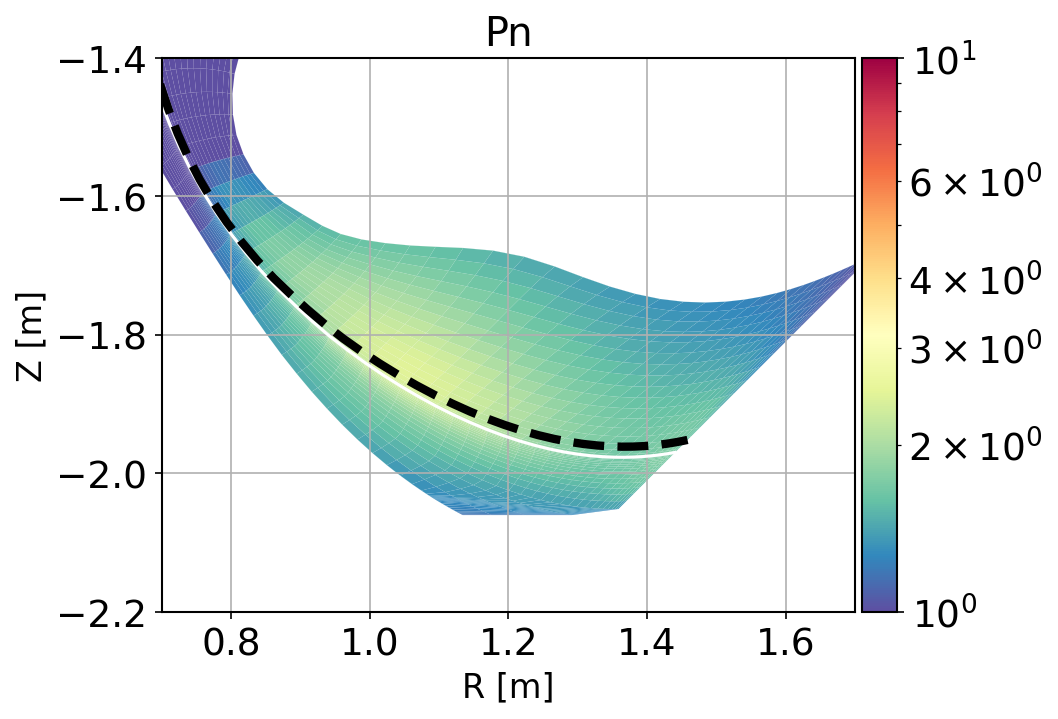

In [6]:
vmin = 1e0
vmax = 1e1

case.plot_2d("Pn", logscale=True, xlim = (0.7,1.7), ylim = (-2.2,-1.4), 
            separatrix = True, vmin = vmin, vmax = vmax, plot_flux_tube = True)

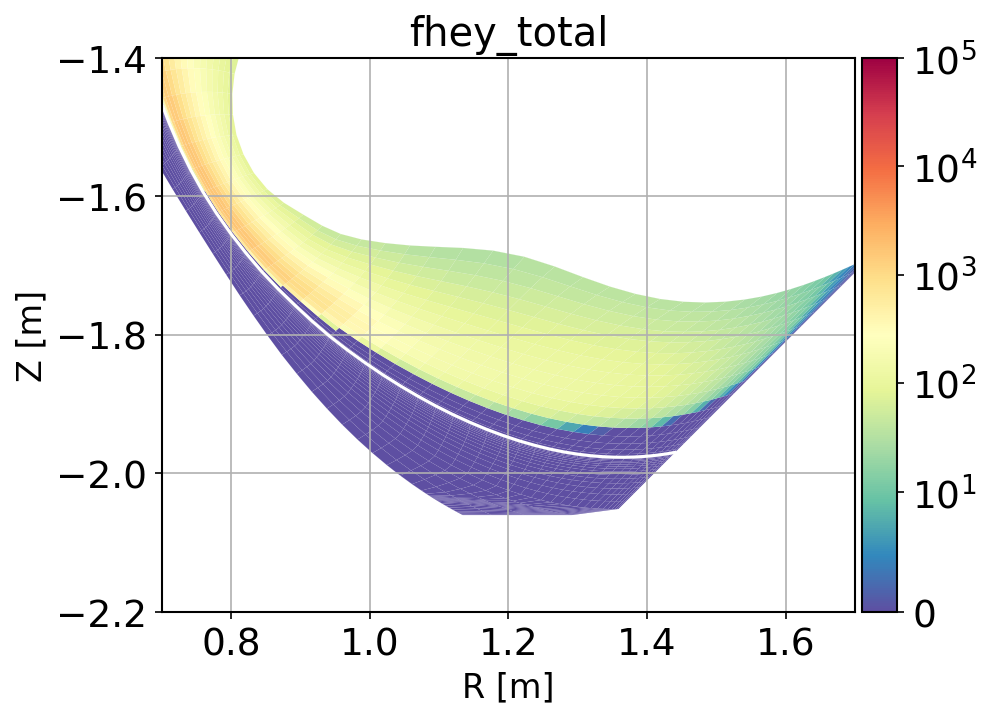

In [17]:
vmin, vmax = 0, 10e4

case.plot_2d("fhey_total", logscale=True, 
separatrix = True, vmin = vmin, vmax = vmax, xlim = (0.7,1.7), ylim = (-2.2,-1.4))

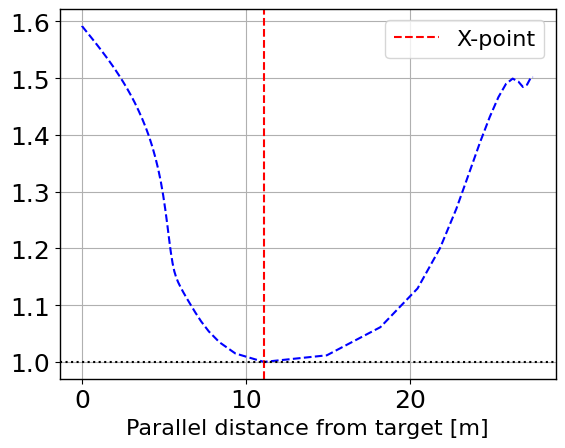

In [8]:
# Get field line data from target to midplane
# sepadd=0 is the separatrix, sepadd=5 is 5 rings into the SOL
fline = case.get_1d_poloidal_data(
    ["Te", "ne", 'Nn', "Pe", 'Btot'], 
    region="outer_lower",  # outer lower divertor leg
    sepadd=0,              # 5th SOL ring
    target_first=True      # Start from target
)


bpol_xpoint = fline[fline['Xpoint']==1]['Btot'].values[0]

# Plot along field line
fig, ax = plt.subplots()
# ax2 = ax.twinx()

# ax.plot(fline["Spar"], fline["Te"])
# ax2.plot(fline['Spar'], fline['Nn'], color = 'black', linestyle = '--')
# ax2.plot(fline['Spar'], fline['ne'], color = 'blue', linestyle = '--')
ax.plot(fline['Spar'],-1 * fline['Btot']/bpol_xpoint + 2, color = 'blue', linestyle = '--')


ax.axvline(fline[fline["Xpoint"]==1]["Spar"].values[0], 
           color='r', linestyle='--', label='X-point')
ax.axhline(1 , color = 'black', linestyle = ':')
ax.set_xlabel("Parallel distance from target [m]")
# ax.set_ylabel("Te [eV]")
# ax2.set_ylabel(r'Ne/Nd ($m^{-3}$)')
ax.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


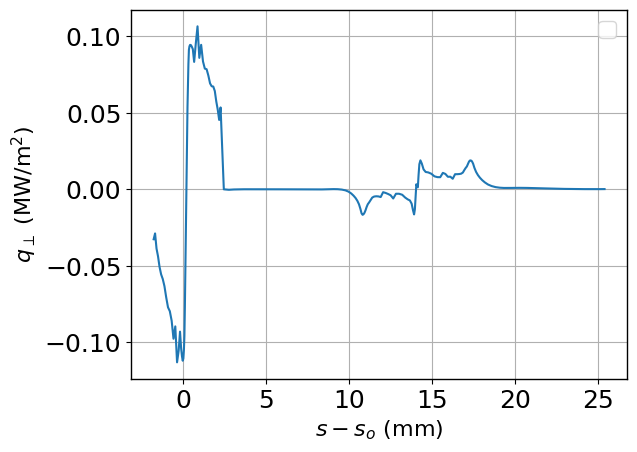

In [ ]:
fline = case.get_1d_radial_data( 
    params = ['fhexy_total'], 
    region = 'outer_lower_target')


fig, ax = plt.subplots()

ax.plot(fline["dist"]*1e3, (fline["fhey_total"]/fline['apar']) * 1e-6)

ax.set_ylabel(r"$q_\perp$ (MW/m$^2$)")
ax.set_xlabel(r'$s - s_o$ (mm)')

ax.legend()

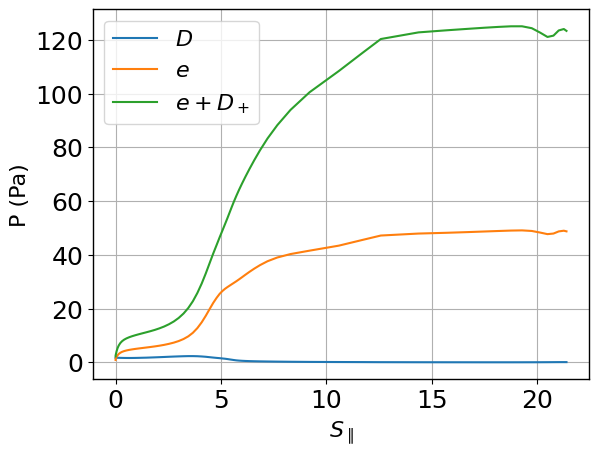

In [10]:
fline = case.get_1d_poloidal_data(
    ["Te", "ne", 'Nn', "Pe", 'Btot', 'Pn', 'Pd+'], 
    region="outer_lower",  # outer lower divertor leg
    sepadd=1,              # 5th SOL ring
    target_first=True      # Start from target
)


fig, ax = plt.subplots()
# ax2 = ax.twinx()

P_ei = fline['Pe'] + fline['Pd+']

# ax.plot(fline["Spar"], (fline["Te"]))
ax.plot(fline['Spar'], fline['Pn'], label = r'$D$')
ax.plot(fline['Spar'], fline['Pe'], label = r'$e$')
ax.plot(fline['Spar'], P_ei, label = r'$e+ D_+$')

ax.set_ylabel(r"P (Pa)")
ax.set_xlabel(r'$S_\parallel$')

ax.legend()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Index(['dist', 'sep', 'apar', 'vol', 'Z', 'Te', 'ne', 'Nn', 'Pe'], dtype='object')


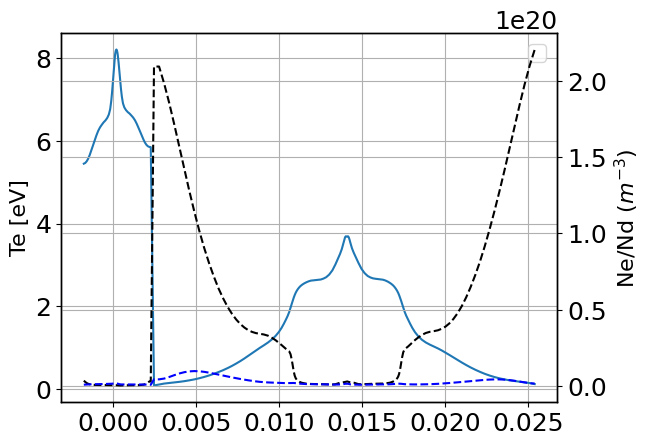

In [11]:
# Get field line data from target to midplane
# sepadd=0 is the separatrix, sepadd=5 is 5 rings into the SOL
fline = case.get_1d_radial_data(
    ["Te", "ne", 'Nn', "Pe"], 
    region="outer_lower_target",  # outer lower divertor leg

)
print(fline.keys())
# Plot along field line
fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(fline["dist"], fline["Te"])
ax2.plot(fline['dist'], fline['Nn'], color = 'black', linestyle = '--')
ax2.plot(fline['dist'], fline['ne'], color = 'blue', linestyle = '--')

# ax.axvline(fline[fline["Xpoint"]==1]["Spar"].values[0], 
#            color='r', linestyle='--', label='X-point')
# ax.set_xlabel("Parallel distance from target [m]")
ax.set_ylabel("Te [eV]")
ax2.set_ylabel(r'Ne/Nd ($m^{-3}$)')
ax.legend()


OUTER TARGET:
  Total power: 0.00 MW
  Total wetted area: 0.0272 m²
  Peak heat flux: 0.1 MW/m²
  SOL wetted area: 0.0269 m²

INNER TARGET:
  Total power: 0.72 MW
  Total wetted area: 0.0285 m²
  Peak heat flux: 187.7 MW/m²
  SOL wetted area: 0.0257 m²


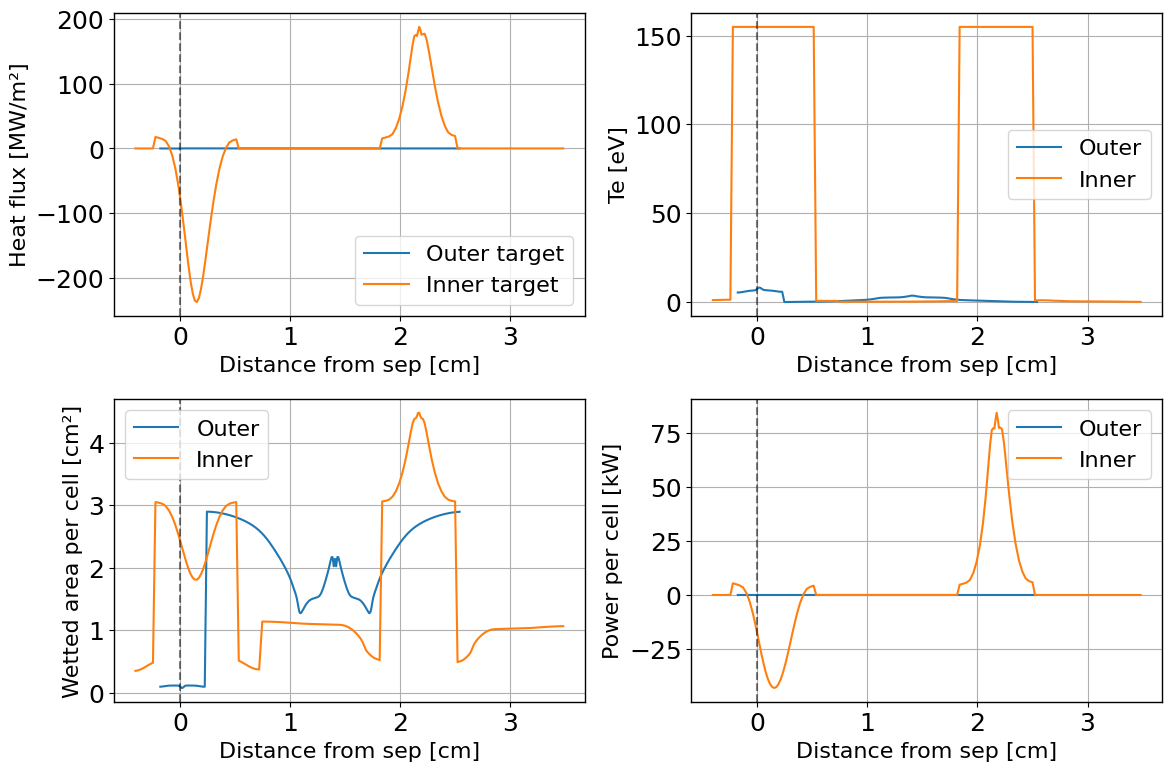

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get both targets
olt = case.get_1d_radial_data(
    ["fhx_total", "apar", "Te", "ne"], 
    region="outer_lower_target"
)
ilt = case.get_1d_radial_data(
    ["fhx_total", "apar", "Te", "ne"], 
    region="inner_lower_target"
)

# Calculate heat flux density
for target in [olt, ilt]:
    target["q"] = target["fhx_total"] / target["apar"] / 1e6  # MW/m²

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Heat flux density
ax = axes[0, 0]
ax.plot(olt["dist"]*100, olt["q"], label='Outer target')
ax.plot(ilt["dist"]*100, ilt["q"], label='Inner target')
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel("Distance from sep [cm]")
ax.set_ylabel("Heat flux [MW/m²]")
ax.legend()

# Temperature
ax = axes[0, 1]
ax.plot(olt["dist"]*100, olt["Te"], label='Outer')
ax.plot(ilt["dist"]*100, ilt["Te"], label='Inner')
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel("Distance from sep [cm]")
ax.set_ylabel("Te [eV]")
ax.legend()

# Wetted area per cell
ax = axes[1, 0]
ax.plot(olt["dist"]*100, olt["apar"]*1e4, label='Outer')
ax.plot(ilt["dist"]*100, ilt["apar"]*1e4, label='Inner')
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel("Distance from sep [cm]")
ax.set_ylabel("Wetted area per cell [cm²]")
ax.legend()

# Power per cell
ax = axes[1, 1]
ax.plot(olt["dist"]*100, olt["fhx_total"]/1e3, label='Outer')
ax.plot(ilt["dist"]*100, ilt["fhx_total"]/1e3, label='Inner')
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel("Distance from sep [cm]")
ax.set_ylabel("Power per cell [kW]")
ax.legend()

plt.tight_layout()

# Print summary
print("\nOUTER TARGET:")
print(f"  Total power: {olt['fhx_total'].sum()/1e6:.2f} MW")
print(f"  Total wetted area: {olt['apar'].sum():.4f} m²")
print(f"  Peak heat flux: {olt['q'].max():.1f} MW/m²")
print(f"  SOL wetted area: {olt[olt['dist']>0]['apar'].sum():.4f} m²")

print("\nINNER TARGET:")
print(f"  Total power: {ilt['fhx_total'].sum()/1e6:.2f} MW")
print(f"  Total wetted area: {ilt['apar'].sum():.4f} m²")
print(f"  Peak heat flux: {ilt['q'].max():.1f} MW/m²")
print(f"  SOL wetted area: {ilt[ilt['dist']>0]['apar'].sum():.4f} m²")